# Pipeline de Modelado para Detección de Vishing — Dataset Aumentado BioCatch (~1M sesiones)

**Iniciativa Anti-Vishing:** Evaluación de modelos base sobre el dataset aumentado sintéticamente.

## Objetivo

Entrenar y evaluar múltiples algoritmos de clasificación (Regresión Logística, Random Forest, XGBoost y Redes Neuronales) iterando sobre los diferentes datasets generados en el proceso de balanceo de datos de la data aumentada. Todo esto usando como base las variables generadas para el dataset aumentado.

**Diferencias clave vs pipeline original:**
- Imbalance severo base: 1:94 (vs 1:19 en el dataset original)
- Sin scores BioCatch (no disponibles en el dataset aumentado)

**Manejo del desbalance:**
- Iteración sobre variantes de balanceo dentro de `data/balanced/augmented/`

**Métrica prioritaria:** PR-AUC y Recall (contexto de detección de fraude con imbalance 1:94)

## 1. Setup e Importaciones
Para evaluar de forma justa, extraemos un set de prueba del dataset aumentado sin balancear, tal como se hizo en el pipeline original.


In [1]:
%pip uninstall -y sagemaker
%pip install "sagemaker<3"

Found existing installation: sagemaker 2.257.3
Uninstalling sagemaker-2.257.3:
  Successfully uninstalled sagemaker-2.257.3
Note: you may need to restart the kernel to use updated packages.
  Using cached sagemaker-2.257.3-py3-none-any.whl (1.7 MB)
  Using cached botocore-1.43.16-py3-none-any.whl (15.1 MB)
  Attempting uninstall: botocore
    Found existing installation: botocore 1.43.0
    Uninstalling botocore-1.43.0:
      Successfully uninstalled botocore-1.43.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 3.7.0 requires botocore<1.43.1,>=1.42.90, but you have botocore 1.43.16 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os
import glob
from pathlib import Path

import boto3
from urllib.parse import urlparse

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [3]:
import sagemaker
print("Versión:", getattr(sagemaker, "__version__", "sin __version__"))
print("Archivo:", getattr(sagemaker, "__file__", "sin __file__"))
print("Tiene Session?:", hasattr(sagemaker, "Session"))
print("Primeros atributos:", dir(sagemaker)[:30])

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
Versión: 2.257.3
Archivo: /home/ec2-user/SageMaker/Vishing_synth_data_GenAI/.venv/lib/python3.10/site-packages/sagemaker/__init__.py
Tiene Session?: True
Primeros atributos: ['AlgorithmEstimator', 'AutoML', 'AutoMLDataChannel', 'AutoMLImageClassificationConfig', 'AutoMLInput', 'AutoMLJob', 'AutoMLJobV2', 'AutoMLTabularConfig', 'AutoMLTextClassificationConfig', 'AutoMLTextGenerationConfig', 'AutoMLTimeSeriesForecastingConfig', 'AutoMLV2', 'CandidateEstimator', 'CandidateStep', 'ContainerBaseModel', 'FactorizationMachines', 'FactorizationMachinesModel', 'FactorizationMachinesPredictor', 'FileSource', 'HyperparameterTuningJobAnalytics', 'IPInsights', 'IPInsightsModel', 'IPInsightsPredictor', 'KMeans', 'KMeansModel', 'KMeansPredictor', 'KNN', 'KNNModel', 'KNNPredictor', 'LDA']


## 2. Configuración de SageMaker y Carga del Dataset Aumentado

El bucket de S3 sigue la misma estructura de directorios que el entorno local.

- `s3://<bucket>/data/augmented_data/dataset_1M_vishing_.parquet`
- `s3://<bucket>/data/balanced/augmented/...`
- `s3://<bucket>/modelos/...`


In [4]:
# --- Configuración de SageMaker ---

sagemaker_session = sagemaker.Session()

bucket = "s3://poc-fraude-vishing" 

bucket = "poc-fraude-vishing"   # ✅ solo el nombre
base_prefix = "proyecto"

s3_prefix_data = f"{base_prefix}/data"
s3_prefix_models = f"{base_prefix}/modelos"

role = sagemaker.get_execution_role()
s3_client = boto3.client('s3')

print(f"Bucket de S3 por defecto: {bucket}")
print(f"Rol de ejecución de SageMaker: {role}")

Bucket de S3 por defecto: poc-fraude-vishing
Rol de ejecución de SageMaker: arn:aws:iam::538430999815:role/demo-moe


In [5]:
# --- Carga de datos desde S3 ---
S3_PARQUET_PATH = f's3://{bucket}/{s3_prefix_data}/augmented_data/dataset_1M_vishing_.parquet'

print(f"\nCargando dataset desde: {S3_PARQUET_PATH}")
df = pd.read_parquet(S3_PARQUET_PATH)
df['session_timestamp'] = pd.to_datetime(df['session_timestamp'])

n_total   = len(df)
n_vishing = int((df['is_vishing'] == 1).sum())
n_legit   = int((df['is_vishing'] == 0).sum())
imbalance_ratio = n_legit // n_vishing

print(f'Dataset aumentado : {n_total:,} filas x {df.shape[1]} columnas')
print(f'  Legítimas       : {n_legit:,}  ({n_legit/n_total*100:.2f}%)')
print(f'  Vishing         : {n_vishing:,}   ({n_vishing/n_total*100:.2f}%)')
print(f'  Imbalance ratio : 1:{imbalance_ratio}')

# ── Extract Hold-out: 20% estratificado (virgen) ──
cols_to_drop = ['session_id', 'customer_id', 'session_timestamp',
           'device_type', 'os_type', 'app_version',
           'biocatch_risk_score', 'biocatch_genuine_score', 'biocatch_ato_indicator', 
           'biocatch_social_eng_indicator', 'biocatch_bot_indicator', 'days_to_claim', 'claim_category',
           'screens_visited', 'unusual_screen_visits',"is_synthetic", "interactions_per_s"]
           
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

X = df_model.drop(columns=['is_vishing'])
y = df_model['is_vishing']

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('\nHOLD-OUT SET (20% del total — virgen)')
print(f'  Total     : {len(X_test):,}')
print(f'  Legítimas : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)')
print(f'  Vishing   : {y_test.sum():,} ({y_test.mean()*100:.2f}%)')

scaler = StandardScaler()



Cargando dataset desde: s3://poc-fraude-vishing/proyecto/data/augmented_data/dataset_1M_vishing_.parquet
Dataset aumentado : 1,000,000 filas x 62 columnas
  Legítimas       : 985,000  (98.50%)
  Vishing         : 15,000   (1.50%)
  Imbalance ratio : 1:65

HOLD-OUT SET (20% del total — virgen)
  Total     : 200,000
  Legítimas : 197,000 (98.50%)
  Vishing   : 3,000 (1.50%)


In [6]:
s3 = boto3.client("s3")

try:
    s3.head_object(
        Bucket="poc-fraude-vishing",
        Key="proyecto/data/augmented_data/dataset_1M_vishing_.parquet"
    )
    print("✅ El objeto existe y tienes permisos")
except Exception as e:
    print("❌ Error:", e)

✅ El objeto existe y tienes permisos


## 3. Definición del Pipeline Multimodelo

Iteraremos a través de cada carpeta y archivo Parquet generado en el proceso de balanceo dentro de `data/balanced/augmented/`.


Definición de MPL Classifier

In [7]:
class PyTorchMLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_sizes=(64, 32), max_iter=20, lr=0.001, batch_size=4096, random_state=42):
        self.hidden_sizes = hidden_sizes
        self.max_iter = max_iter
        self.lr = lr
        self.batch_size = batch_size
        self.random_state = random_state
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = None

    def _build_model(self, input_dim):
        torch.manual_seed(self.random_state)
        layers = []
        in_dim = input_dim
        for h in self.hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        return nn.Sequential(*layers).to(self.device)

    def fit(self, X, y):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_array = y.values if hasattr(y, 'values') else y
        y_tensor = torch.tensor(y_array, dtype=torch.float32).unsqueeze(1)
        
        self.model = self._build_model(X.shape[1])
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for epoch in range(self.max_iter):
            for batch_X, batch_y in dataloader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.to(self.device) # <-- Agregado: garantizar que el modelo está en el device
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            logits = self.model(X_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()
        return np.hstack([1 - probs, probs])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)

    def __getstate__(self):
        state = self.__dict__.copy()
        if self.model is not None:
            state['model'] = self.model.cpu() # Lo enviamos a cpu para serializar bien a S3
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        # Omitimos enviar a device en setstate, lo maneja predict_proba y fit cuando se requiera

In [ ]:
import json as _json
import copy

class VishingModelWrapper:
    """
    Bundles a trained classifier with its scaler, ordered feature list, and
    optimal decision threshold so that inference can be driven purely by a
    named-feature JSON — no positional assumptions required.

    Supports single observations (dict or JSON string) and batches (list of dicts).
    """

    def __init__(self, model, feature_names, scaler=None, threshold=0.5,
                 model_name="", technique="", ratio=""):
        self.model         = model
        self.feature_names = list(feature_names)
        self.scaler        = scaler        # None for tree-based models
        self.threshold     = threshold
        self.model_name    = model_name
        self.technique     = technique
        self.ratio         = ratio

    # ── input normalisation ──────────────────────────────────────────────────
    def _to_array(self, json_input):
        """Convert dict / JSON string / list-of-dicts → scaled numpy array."""
        if isinstance(json_input, str):
            data = _json.loads(json_input)
        elif isinstance(json_input, dict):
            data = json_input
        elif isinstance(json_input, list):
            return np.vstack([self._to_array(item) for item in json_input])
        else:
            raise TypeError(f"Expected dict, JSON string, or list of dicts. Got {type(json_input)}")

        missing = set(self.feature_names) - set(data.keys())
        if missing:
            raise ValueError(f"Missing features: {sorted(missing)}")

        X = np.array([[data[f] for f in self.feature_names]], dtype=np.float64)
        if self.scaler is not None:
            X = self.scaler.transform(X)
        return X

    # ── public API ───────────────────────────────────────────────────────────
    def predict(self, json_input):
        """Returns 0 (legitimate) or 1 (vishing) using the stored threshold."""
        proba  = self.model.predict_proba(self._to_array(json_input))[:, 1]
        labels = (proba >= self.threshold).astype(int).tolist()
        return labels[0] if len(labels) == 1 else labels

    def predict_proba_raw(self, json_input):
        """Returns {'legitimate': float, 'vishing': float} per observation."""
        proba = self.model.predict_proba(self._to_array(json_input))
        rows  = [{"legitimate": round(float(p[0]), 6),
                  "vishing":    round(float(p[1]), 6)} for p in proba]
        return rows[0] if len(rows) == 1 else rows

    def predict_full(self, json_input):
        """
        Full inference result per observation:
          prediction, label, probability_vishing, probability_legitimate, threshold_used
        Accepts a single dict/JSON string or a list of dicts for batch.
        """
        proba   = self.model.predict_proba(self._to_array(json_input))
        results = []
        for p in proba:
            label = int(p[1] >= self.threshold)
            results.append({
                "prediction":             label,
                "label":                  "vishing" if label == 1 else "legitimate",
                "probability_vishing":    round(float(p[1]), 6),
                "probability_legitimate": round(float(p[0]), 6),
                "threshold_used":         round(self.threshold, 6),
            })
        return results[0] if len(results) == 1 else results

    def __repr__(self):
        return (f"VishingModelWrapper(model={self.model_name!r}, "
                f"technique={self.technique!r}, ratio={self.ratio!r}, "
                f"n_features={len(self.feature_names)}, threshold={self.threshold:.4f})")


Pipeline

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(tree_method='hist', device='cuda', use_label_encoder=False, eval_metric='logloss', max_depth=6, learning_rate=0.1, random_state=42),
    'Deep Learning (PyTorch)': PyTorchMLPWrapper(hidden_sizes=(64, 32), max_iter=30, batch_size=4096, random_state=42) # Implementación PyTorch en GPU
}

# --- Listar datasets balanceados en S3 ---
s3_balanced_path = f'{s3_prefix_data}/balanced/augmented/'
response = s3_client.list_objects_v2(Bucket=bucket, Prefix=s3_balanced_path)

data_paths = []
if 'Contents' in response:
    for obj in response['Contents']:
        key = obj['Key']
        if key.endswith('.parquet'):
            data_paths.append(f's3://{bucket}/{key}')

# --- Añadir el dataset original sin balancear ---
original_data_path = f's3://{bucket}/{s3_prefix_data}/augmented_data/dataset_1M_vishing_.parquet'
if original_data_path not in data_paths:
    data_paths.append(original_data_path)

results = []
print(f"Detectados {len(data_paths) - 1} datasets balanceados y 1 dataset original en S3 para evaluación. Total datasets: {len(data_paths)}")

Detectados 12 datasets balanceados y 1 dataset original en S3 para evaluación. Total datasets: 13


In [ ]:
import joblib
import copy
from io import BytesIO

for path in data_paths:
    parsed_url = urlparse(path)
    key = parsed_url.path.lstrip('/')

    parts     = key.split('/')
    technique = parts[-2]
    ratio     = Path(parts[-1]).stem

    print(f"\n--- Evaluando {technique} / {ratio} desde S3 ---")

    local_model_dir = Path(f"modelos_temp/{technique}/{ratio}")
    local_model_dir.mkdir(parents=True, exist_ok=True)

    df_train = pd.read_parquet(path)
    df_train = df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns], errors='ignore')

    X_train = df_train.drop(columns=['is_vishing'])
    y_train = df_train['is_vishing']

    # Alinear columnas con el hold-out y fijar orden canónico de features
    X_train       = X_train[X_test.columns]
    feature_names = X_test.columns.tolist()

    # Scaler propio por dataset — se persistirá dentro del wrapper
    scaler_ds = StandardScaler()
    scaler_ds.fit(X_train)
    X_train_scaled = scaler_ds.transform(X_train)
    X_test_scaled  = scaler_ds.transform(X_test)

    for model_name, model in models.items():
        needs_scaling = model_name in ['Logistic Regression', 'Deep Learning (PyTorch)']
        X_tr = X_train_scaled if needs_scaling else X_train.values
        X_te = X_test_scaled  if needs_scaling else X_test.values

        model.fit(X_tr, y_train)

        # Umbral óptimo por F1 máximo sobre el hold-out
        y_prob_eval = model.predict_proba(X_te)[:, 1]
        prec_t, rec_t, thr_t = precision_recall_curve(y_test, y_prob_eval)
        f1_t = 2 * prec_t[:-1] * rec_t[:-1] / (prec_t[:-1] + rec_t[:-1] + 1e-9)
        optimal_threshold = float(thr_t[np.argmax(f1_t)])

        # Empaquetar en VishingModelWrapper: modelo + scaler + features + umbral
        wrapper = VishingModelWrapper(
            model         = copy.deepcopy(model),
            feature_names = feature_names,
            scaler        = copy.deepcopy(scaler_ds) if needs_scaling else None,
            threshold     = optimal_threshold,
            model_name    = model_name,
            technique     = technique,
            ratio         = ratio,
        )

        # Serializar wrapper y subir a S3
        safe_name        = model_name.replace(' ', '_').replace('(', '').replace(')', '')
        local_model_path = local_model_dir / f"{safe_name}.pkl"
        joblib.dump(wrapper, local_model_path)

        s3_model_key = f'{s3_prefix_models}/{technique}/{ratio}/{safe_name}.pkl'
        s3_client.upload_file(str(local_model_path), bucket, s3_model_key)

        # Métricas con umbral óptimo
        y_pred = (y_prob_eval >= optimal_threshold).astype(int)

        results.append({
            'Technique'    : technique,
            'Ratio_%'      : ratio,
            'Model'        : model_name,
            'Threshold'    : round(optimal_threshold, 4),
            'Recall'       : recall_score(y_test, y_pred),
            'Precision'    : precision_score(y_test, y_pred),
            'F1'           : f1_score(y_test, y_pred),
            'ROC_AUC'      : roc_auc_score(y_test, y_prob_eval),
            'PR_AUC'       : average_precision_score(y_test, y_prob_eval),
            'S3_Model_Path': f's3://{bucket}/{s3_model_key}',
        })

print(f"\n¡Pipeline finalizado! Wrappers guardados en s3://{bucket}/{s3_prefix_models}/")


## 4. Análisis de Resultados e Identificación de la Mejor Estrategia


In [10]:
df_results = pd.DataFrame(results)

df_results_sorted = df_results.sort_values(by='PR_AUC', ascending=False)
display(df_results_sorted.head(15).style.background_gradient(cmap='viridis', subset=['Recall', 'PR_AUC', 'ROC_AUC']))


,Technique,Ratio_%,Model,Recall,Precision,F1,ROC_AUC,PR_AUC,S3_Model_Path
14,random_oversampling,10,XGBoost,0.861333,0.494167,0.628023,0.993910,0.797542,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/10/XGBoost.pkl
50,augmented_data,dataset_1M_vishing_,XGBoost,0.587667,0.841929,0.692187,0.993344,0.794308,s3://poc-fraude-vishing/proyecto/modelos/augmented_data/dataset_1M_vishing_/XGBoost.pkl
18,random_oversampling,20,XGBoost,0.937667,0.333294,0.491783,0.994020,0.792472,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/20/XGBoost.pkl
22,random_oversampling,25,XGBoost,0.953333,0.294785,0.450323,0.993993,0.792012,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/25/XGBoost.pkl
49,augmented_data,dataset_1M_vishing_,Random Forest,0.001667,1.000000,0.003328,0.989658,0.728071,s3://poc-fraude-vishing/proyecto/modelos/augmented_data/dataset_1M_vishing_/Random_Forest.pkl
2,borderline_smote,10,XGBoost,0.672333,0.621380,0.645853,0.990688,0.703235,s3://poc-fraude-vishing/proyecto/modelos/borderline_smote/10/XGBoost.pkl
26,smote,10,XGBoost,0.700000,0.593220,0.642202,0.990622,0.698371,s3://poc-fraude-vishing/proyecto/modelos/smote/10/XGBoost.pkl
38,smote_undersampling,10,XGBoost,0.710333,0.579233,0.638119,0.990560,0.696818,s3://poc-fraude-vishing/proyecto/modelos/smote_undersampling/10/XGBoost.pkl
13,random_oversampling,10,Random Forest,0.508333,0.682938,0.582840,0.990145,0.691520,s3://poc-fraude-vishing/proyecto/modelos/random_oversampling/10/Random_Forest.pkl
6,borderline_smote,20,XGBoost,0.705000,0.539266,0.611095,0.989669,0.668388,s3://poc-fraude-vishing/proyecto/modelos/borderline_smote/20/XGBoost.pkl


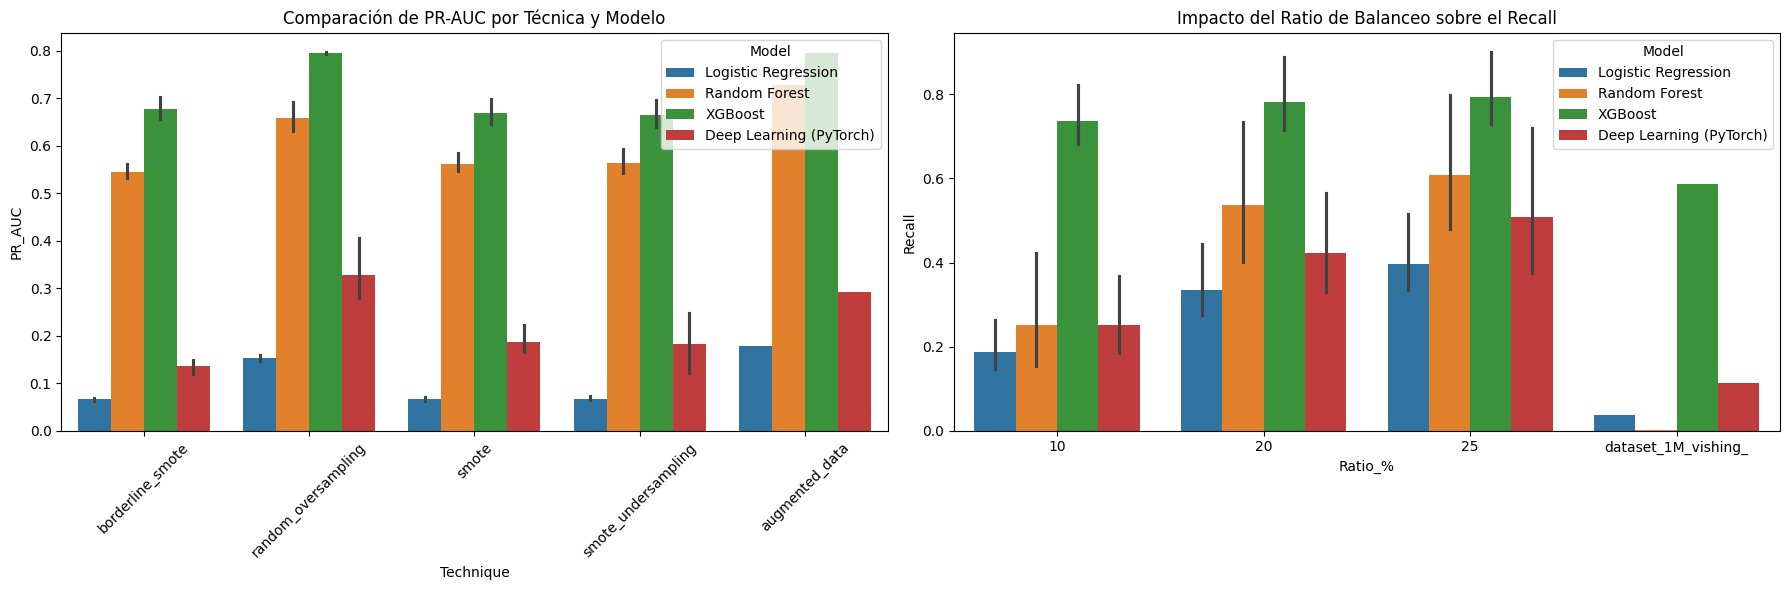

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_results, x='Technique', y='PR_AUC', hue='Model', ax=ax1)
ax1.set_title('Comparación de PR-AUC por Técnica y Modelo')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

sns.barplot(data=df_results, x='Ratio_%', y='Recall', hue='Model', ax=ax2)
ax2.set_title('Impacto del Ratio de Balanceo sobre el Recall')

plt.tight_layout()
plt.show()


## 5. Analisis del Mejor Modelo (Matriz de Confusion)

Seleccionaremos la combinación de Técnica, Ratio y Modelo que obtuvo el mejor PR-AUC y trazaremos su matriz de confusión sobre el Hold-Out Set.


In [ ]:
best_row           = df_results_sorted.iloc[0]
best_technique     = best_row['Technique']
best_ratio         = best_row['Ratio_%']
best_model_name    = best_row['Model']
s3_best_model_path = best_row['S3_Model_Path']

print(f"--- Mejor combinación identificada (por PR-AUC) ---")
print(f"Modelo        : {best_model_name}")
print(f"Técnica       : {best_technique}")
print(f"Ratio         : {best_ratio}%")
print(f"PR_AUC        : {best_row['PR_AUC']:.4f}")
print(f"Umbral óptimo : {best_row['Threshold']:.4f}")
print(f"Ubicación S3  : {s3_best_model_path}")

# ── Cargar el VishingModelWrapper desde S3 ───────────────────────────────────
from io import BytesIO
parsed_url   = urlparse(s3_best_model_path)
s3_model_key = parsed_url.path.lstrip('/')

with BytesIO() as f:
    s3_client.download_fileobj(Bucket=bucket, Key=s3_model_key, Fileobj=f)
    f.seek(0)
    best_wrapper = joblib.load(f)

print(f"\nWrapper cargado : {best_wrapper}")
print(f"Features        : {len(best_wrapper.feature_names)} columnas")
print(f"Umbral interno  : {best_wrapper.threshold:.4f}")
print(f"Scaler incluido : {'Sí' if best_wrapper.scaler is not None else 'No (árbol, no requiere)'}")

# ── Evaluación sobre el hold-out usando el wrapper ───────────────────────────
X_test_ordered = X_test[best_wrapper.feature_names]
if best_wrapper.scaler is not None:
    X_te_best = best_wrapper.scaler.transform(X_test_ordered)
else:
    X_te_best = X_test_ordered.values

y_prob_best = best_wrapper.model.predict_proba(X_te_best)[:, 1]
y_pred_best = (y_prob_best >= best_wrapper.threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Legítimo (pred)', 'Vishing (pred)'],
    yticklabels=['Legítimo (real)', 'Vishing (real)']
)
axes[0].set_title('Matriz de Confusión — Conteos', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Clase Predicha')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
    xticklabels=['Legítimo (pred)', 'Vishing (pred)'],
    yticklabels=['Legítimo (real)', 'Vishing (real)']
)
axes[1].set_title('Matriz de Confusión — Normalizada', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Clase Predicha')

plt.suptitle(f'{best_model_name} · {best_technique} {best_ratio}% · Hold-out set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"  Verdaderos Negativos (TN) : {tn:>6}  — Legítimos correctamente identificados")
print(f"  Falsos Positivos     (FP) : {fp:>6}  — Legítimos marcados como Vishing")
print(f"  Falsos Negativos     (FN) : {fn:>6}  — Vishing no detectados  ← riesgo crítico")
print(f"  Verdaderos Positivos (TP) : {tp:>6}  — Vishing correctamente detectados")
print(f"{'='*50}")
print(f"  Recall    (Sensibilidad)  : {tp/(tp+fn):.4f}")
print(f"  Precision                 : {tp/(tp+fp):.4f}")
print(f"  F1-Score                  : {2*tp/(2*tp+fp+fn):.4f}")
print(f"  ROC-AUC                   : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  PR-AUC                    : {average_precision_score(y_test, y_prob_best):.4f}")
print(f"{'='*50}")


## 6. Feature Importance — XGBoost

XGBoost ofrece interpretabilidad nativa via importancia de variables por Gain acumulado.


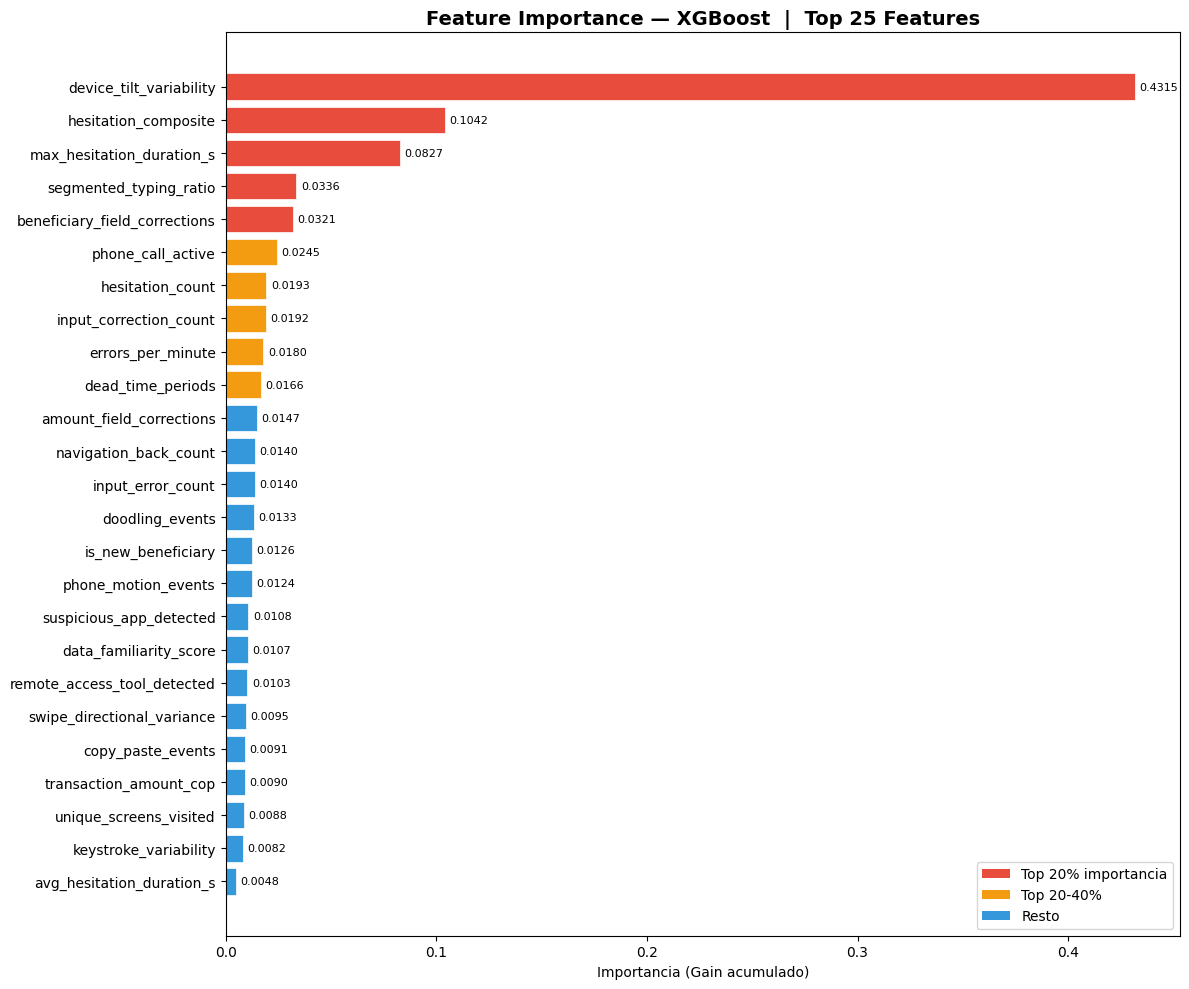

Top 15 features (XGBoost — Gain):
Feature                                   Importancia
-------------------------------------------------------
device_tilt_variability                        0.4315
hesitation_composite                           0.1042
max_hesitation_duration_s                      0.0827
segmented_typing_ratio                         0.0336
beneficiary_field_corrections                  0.0321
phone_call_active                              0.0245
hesitation_count                               0.0193
input_correction_count                         0.0192
errors_per_minute                              0.0180
dead_time_periods                              0.0166
amount_field_corrections                       0.0147
navigation_back_count                          0.0140
input_error_count                              0.0140
doodling_events                                0.0133
is_new_beneficiary                             0.0126


In [13]:
if 'XGBoost' in models:
    xgb_model = models['XGBoost']
    # If the model wasn't trained in the last cell due to not being the best, we must fit it on some dataset. 
    # For now, let's use the 'best' dataset to see the feature importances on the best balanced strategy.
    
    xgb_model.fit(X_best.values, y_best) # X_best and y_best were loaded in previous cell

    FEATURE_NAMES = X_test.columns.tolist()

    fi = pd.DataFrame({
        'feature'   : FEATURE_NAMES,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 10))
    top_fi = fi.head(25)

    q80 = top_fi['importance'].quantile(0.80)
    q60 = top_fi['importance'].quantile(0.60)
    colors_fi = ['#e74c3c' if v >= q80 else '#f39c12' if v >= q60 else '#3498db'
                 for v in top_fi['importance']]

    bars = ax.barh(range(len(top_fi)), top_fi['importance'].values,
                   color=colors_fi, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top_fi)))
    ax.set_yticklabels(top_fi['feature'].values)
    ax.set_xlabel('Importancia (Gain acumulado)')
    ax.set_title('Feature Importance — XGBoost  |  Top 25 Features', fontweight='bold', fontsize=14)
    ax.invert_yaxis()
    for i, v in enumerate(top_fi['importance'].values):
        ax.text(v + top_fi['importance'].max()*0.005, i, f'{v:.4f}', va='center', fontsize=8)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='#e74c3c', label='Top 20% importancia'),
        Patch(facecolor='#f39c12', label='Top 20-40%'),
        Patch(facecolor='#3498db', label='Resto'),
    ], loc='lower right')

    plt.tight_layout()
    plt.show()
    
    print('Top 15 features (XGBoost — Gain):')
    print(f"{'Feature':40s} {'Importancia':>12s}")
    print('-' * 55)
    for _, row in fi.head(15).iterrows():
        print(f"{row['feature']:40s} {row['importance']:12.4f}")
else:
    print("XGBoost no está en el diccionario de modelos, no se grafican importancias.")


<VSCode.Cell id="#VSC-b1dbbf8b" language="markdown">
## 7. Curva Precision-Recall y Analisis de Umbral de Decision
</VSCode.Cell>

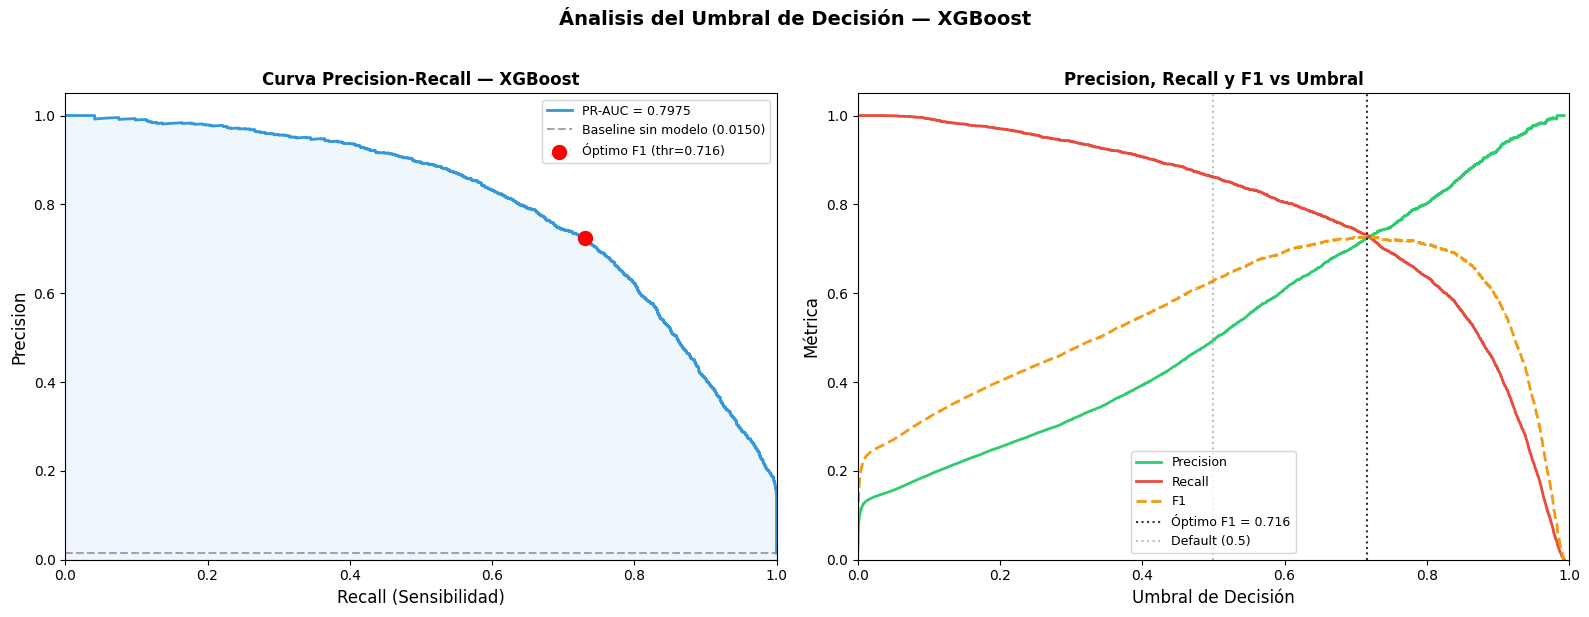

  Con umbral óptimo (max F1) = 0.7161
    Recall    : 0.7313
    Precision : 0.7243
    F1        : 0.7278
  Con umbral por defecto = 0.5
    Recall    : 0.8613
    Precision : 0.4942
    F1        : 0.6280


In [14]:
precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_test, y_prob_best)
pr_auc_val = average_precision_score(y_test, y_prob_best)

f1_scores_c = (2 * precisions_c[:-1] * recalls_c[:-1]
               / (precisions_c[:-1] + recalls_c[:-1] + 1e-9))
best_idx  = np.argmax(f1_scores_c)
best_thr  = thresholds_c[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curva PR
axes[0].plot(recalls_c, precisions_c, color='#3498db', linewidth=2,
             label=f'PR-AUC = {pr_auc_val:.4f}')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.7,
                label=f'Baseline sin modelo ({y_test.mean():.4f})')
axes[0].fill_between(recalls_c, precisions_c, alpha=0.08, color='#3498db')
axes[0].scatter([recalls_c[best_idx]], [precisions_c[best_idx]], s=100,
                color='red', zorder=5, label=f'Óptimo F1 (thr={best_thr:.3f})')
axes[0].set_xlabel('Recall (Sensibilidad)', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title(f'Curva Precision-Recall — {best_model_name}', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)

# Metricas vs umbral
axes[1].plot(thresholds_c, precisions_c[:-1], label='Precision', color='#2ecc71', linewidth=2)
axes[1].plot(thresholds_c, recalls_c[:-1],    label='Recall',    color='#e74c3c', linewidth=2)
axes[1].plot(thresholds_c, f1_scores_c,       label='F1',        color='#f39c12', linewidth=2, linestyle='--')
axes[1].axvline(x=best_thr, color='black', linestyle=':', alpha=0.8,
                label=f'Óptimo F1 = {best_thr:.3f}')
axes[1].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Default (0.5)')
axes[1].set_xlabel('Umbral de Decisión', fontsize=12)
axes[1].set_ylabel('Métrica', fontsize=12)
axes[1].set_title('Precision, Recall y F1 vs Umbral', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)

plt.suptitle(f'Ánalisis del Umbral de Decisión — {best_model_name}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

y_pred_opt = (y_prob_best >= best_thr).astype(int)

print(f"{'='*62}")
print(f"  Con umbral óptimo (max F1) = {best_thr:.4f}")
print(f"    Recall    : {recall_score(y_test, y_pred_opt):.4f}")
print(f"    Precision : {precision_score(y_test, y_pred_opt):.4f}")
print(f"    F1        : {f1_score(y_test, y_pred_opt):.4f}")
print(f"{'='*62}")
print(f"  Con umbral por defecto = 0.5")
print(f"    Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"    Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"    F1        : {f1_score(y_test, y_pred_best):.4f}")
print(f"{'='*62}")


## 8. Inferencia desde JSON — uso en producción

Cada wrapper serializado expone tres métodos que aceptan un JSON con features por nombre:

| Método | Output |
|---|---|
| `predict(json)` | `0` (legítimo) o `1` (vishing) |
| `predict_proba_raw(json)` | `{"legitimate": float, "vishing": float}` |
| `predict_full(json)` | dict completo: label + probabilidades + umbral usado |

Todos aceptan un `dict`, un `str` JSON, o una `list[dict]` para batch.

In [ ]:
import json

# ── Cargar cualquier wrapper desde S3 ────────────────────────────────────────
# (best_wrapper ya está en memoria desde la celda anterior; este bloque muestra
#  cómo cargarlo en un servicio externo a partir de su ruta S3)
#
# s3_path = "s3://poc-fraude-vishing/proyecto/modelos/smote/20/XGBoost.pkl"
# parsed  = urlparse(s3_path)
# with BytesIO() as f:
#     s3_client.download_fileobj(Bucket="poc-fraude-vishing",
#                                Key=parsed.path.lstrip('/'), Fileobj=f)
#     f.seek(0)
#     wrapper = joblib.load(f)

wrapper = best_wrapper   # reutilizamos el cargado en la celda anterior

# ── 1. Caso individual — JSON string (simulando entrada REST) ─────────────────
sample_idx    = X_test[y_test == 1].index[0]       # tomamos un vishing real
sample_record = X_test.loc[sample_idx].to_dict()
sample_json   = json.dumps(sample_record)

print("=== predict_full() — observación individual (JSON string) ===")
result = wrapper.predict_full(sample_json)
print(json.dumps(result, indent=2))

# ── 2. Caso individual — dict ─────────────────────────────────────────────────
print("\n=== predict() y predict_proba_raw() — dict ===")
print("  predict         :", wrapper.predict(sample_record))         # 0 o 1
print("  predict_proba_raw:", wrapper.predict_proba_raw(sample_record))  # probs

# ── 3. Batch — lista de dicts ─────────────────────────────────────────────────
print("\n=== predict_full() — batch (5 observaciones) ===")
batch         = X_test.head(5).to_dict(orient='records')
batch_results = wrapper.predict_full(batch)
for i, r in enumerate(batch_results):
    print(f"  Obs {i}: {r['label']:12s}  "
          f"P_vishing={r['probability_vishing']:.6f}  "
          f"thr={r['threshold_used']}")

# ── 4. Validación: feature faltante ──────────────────────────────────────────
print("\n=== Validación: input con una feature faltante ===")
bad_input = {k: v for k, v in sample_record.items()
             if k != wrapper.feature_names[0]}
try:
    wrapper.predict_full(bad_input)
except ValueError as e:
    print(f"  Error capturado correctamente → {e}")

# ── 5. Listado de features esperadas ─────────────────────────────────────────
print(f"\n=== Features que espera este wrapper ({len(wrapper.feature_names)} total) ===")
for i, feat in enumerate(wrapper.feature_names):
    print(f"  [{i:2d}] {feat}")
